# Clasificación biomecánica de pacientes
## Comparación entre regresión logística y árbol de decisión

# Carga de dataset

In [2]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("uciml/biomechanical-features-of-orthopedic-patients")

print("Ruta del dataset:", path)

# Ver los archivos descargados
print(os.listdir(path))

Ruta del dataset: C:\Users\ivan_\.cache\kagglehub\datasets\uciml\biomechanical-features-of-orthopedic-patients\versions\1
['column_2C_weka.csv', 'column_3C_weka.csv']


In [3]:
archivo = os.path.join(path, 'column_2C_weka.csv')

df = pd.read_csv(archivo)

Ver número de filas y columnas

In [5]:
print("Número de filas y columnas:", df.shape)

Número de filas y columnas: (310, 7)


Ver nombres de las columnas

In [7]:
print("Nombres de columnas:", df.columns)

Nombres de columnas: Index(['pelvic_incidence', 'pelvic_tilt numeric', 'lumbar_lordosis_angle',
       'sacral_slope', 'pelvic_radius', 'degree_spondylolisthesis', 'class'],
      dtype='object')


Ver información de tipos de datos y valores nulos

In [9]:
print("\nInformación del dataset:")
df.info()


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          310 non-null    float64
 1   pelvic_tilt numeric       310 non-null    float64
 2   lumbar_lordosis_angle     310 non-null    float64
 3   sacral_slope              310 non-null    float64
 4   pelvic_radius             310 non-null    float64
 5   degree_spondylolisthesis  310 non-null    float64
 6   class                     310 non-null    object 
dtypes: float64(6), object(1)
memory usage: 17.1+ KB


Ver las primeras 5 filas del dataset

In [11]:
print("\nPrimeras 5 filas:")
print(df.head())


Primeras 5 filas:
   pelvic_incidence  pelvic_tilt numeric  lumbar_lordosis_angle  sacral_slope  \
0         63.027817            22.552586              39.609117     40.475232   
1         39.056951            10.060991              25.015378     28.995960   
2         68.832021            22.218482              50.092194     46.613539   
3         69.297008            24.652878              44.311238     44.644130   
4         49.712859             9.652075              28.317406     40.060784   

   pelvic_radius  degree_spondylolisthesis     class  
0      98.672917                 -0.254400  Abnormal  
1     114.405425                  4.564259  Abnormal  
2     105.985135                 -3.530317  Abnormal  
3     101.868495                 11.211523  Abnormal  
4     108.168725                  7.918501  Abnormal  


Ver la distribución de la variable objetivo (class)

In [13]:
print("\nDistribución de la variable 'class':")
print(df['class'].value_counts())


Distribución de la variable 'class':
class
Abnormal    210
Normal      100
Name: count, dtype: int64


# Analisis exploratorio de los datos

In [15]:
# Ver estadística descriptiva de las variables numéricas
print("Estadística descriptiva:")
df.describe()

Estadística descriptiva:


,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


## Histogramas

In [17]:
# Importar librerías para gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo de los gráficos
sns.set(style="whitegrid")

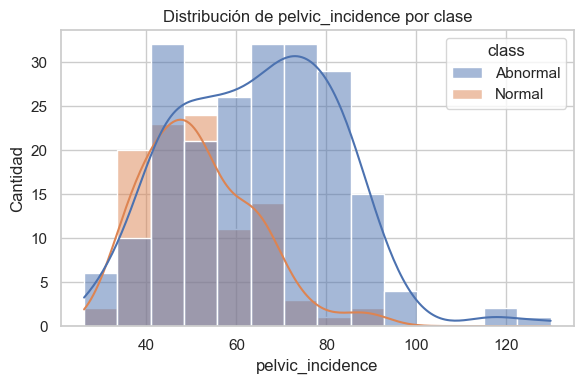

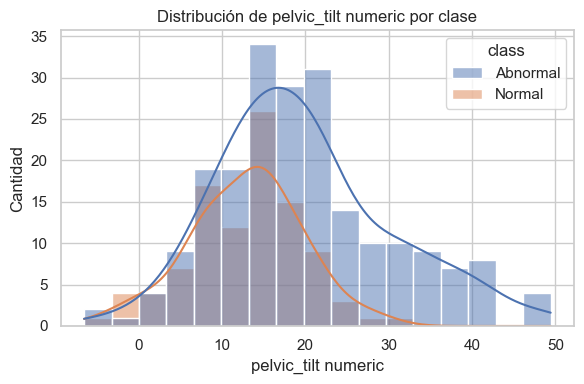

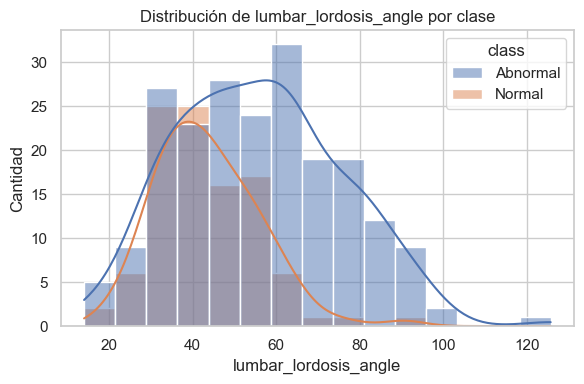

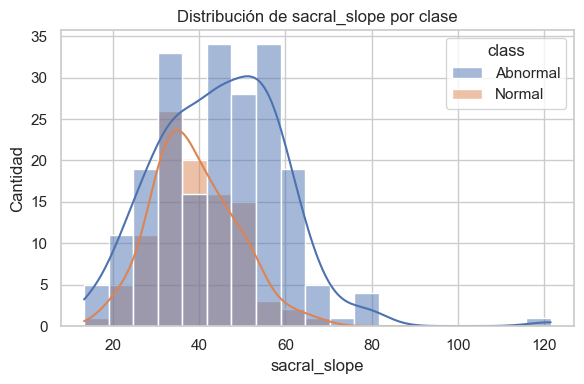

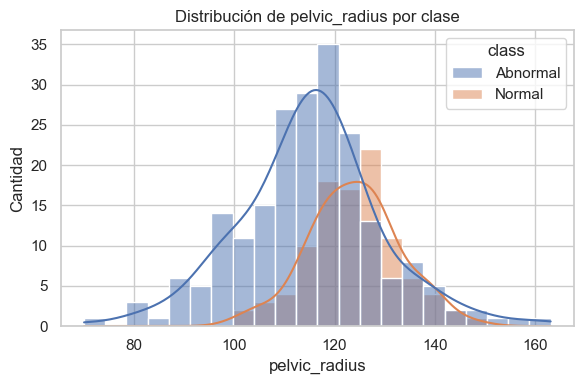

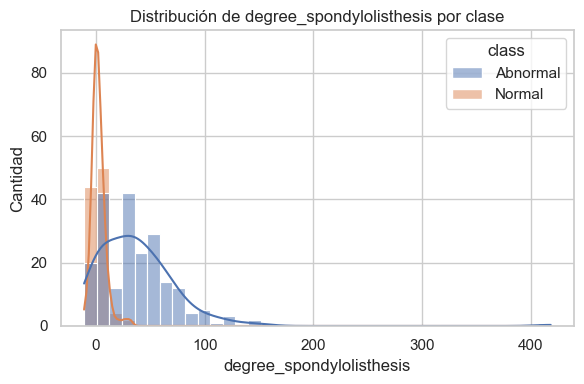

In [18]:
# Lista de las columnas numéricas (features)
features = [
    "pelvic_incidence",
    "pelvic_tilt numeric",
    "lumbar_lordosis_angle",
    "sacral_slope",
    "pelvic_radius",
    "degree_spondylolisthesis"
]

# Crear un gráfico para cada feature
for feature in features:
    plt.figure(figsize=(6, 4))
    
    # Gráfico por clase: Normal vs Abnormal
    sns.histplot(df, x=feature, hue="class", kde=True)
    
    plt.title(f"Distribución de {feature} por clase")
    plt.xlabel(feature)
    plt.ylabel("Cantidad")
    
    plt.tight_layout()
    plt.show()

## Boxplots por clase (Normal / Abnormal)

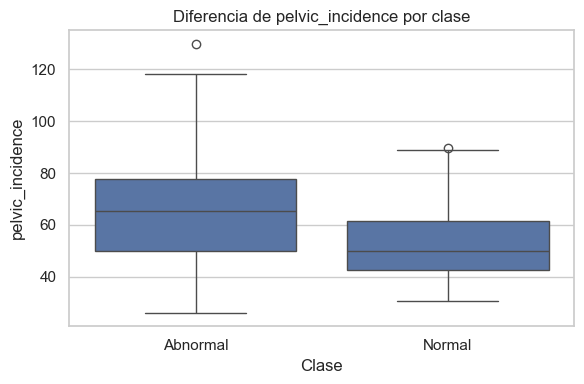

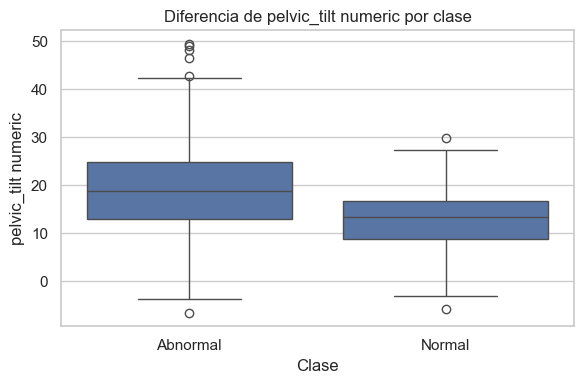

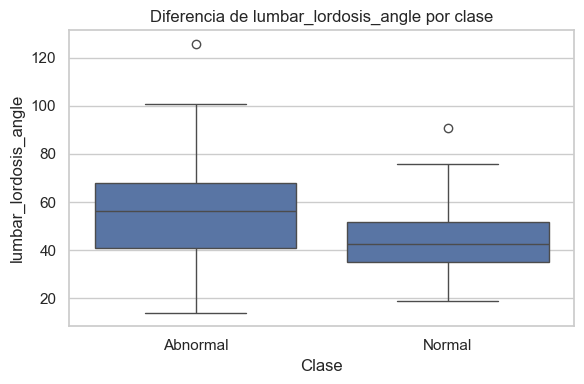

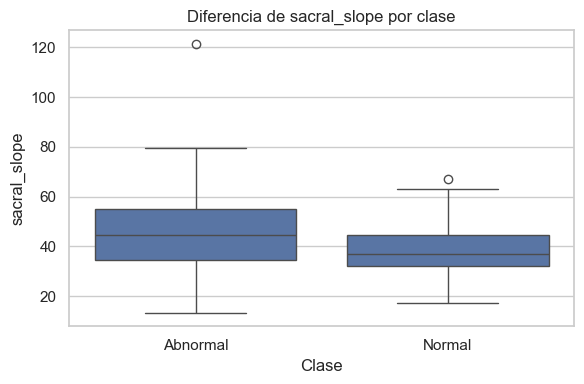

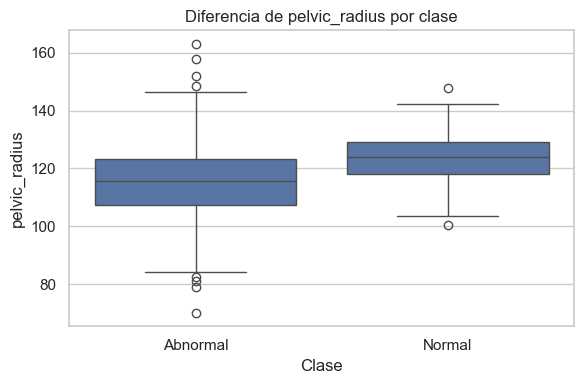

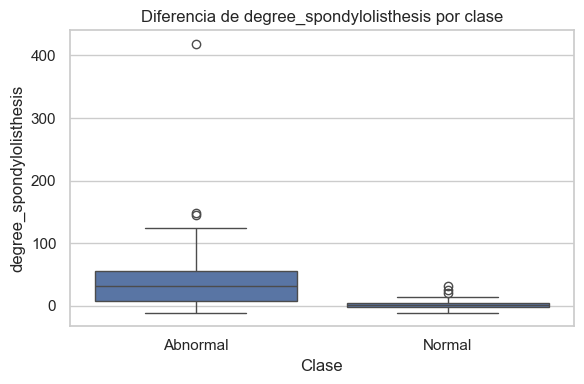

In [20]:
# Crear un boxplot para cada feature por clase
for feature in features:
    plt.figure(figsize=(6, 4))
    
    sns.boxplot(df, x="class", y=feature)
    
    plt.title(f"Diferencia de {feature} por clase")
    plt.xlabel("Clase")
    plt.ylabel(feature)
    
    plt.tight_layout()
    plt.show()

Se pueden observar valores atipicos para Normal como Abnormal. Estos valores atipicos pueden indicar pacientes con valores muy extremos que el modelo debe aprender a clasificar.

## Mapa de correlación

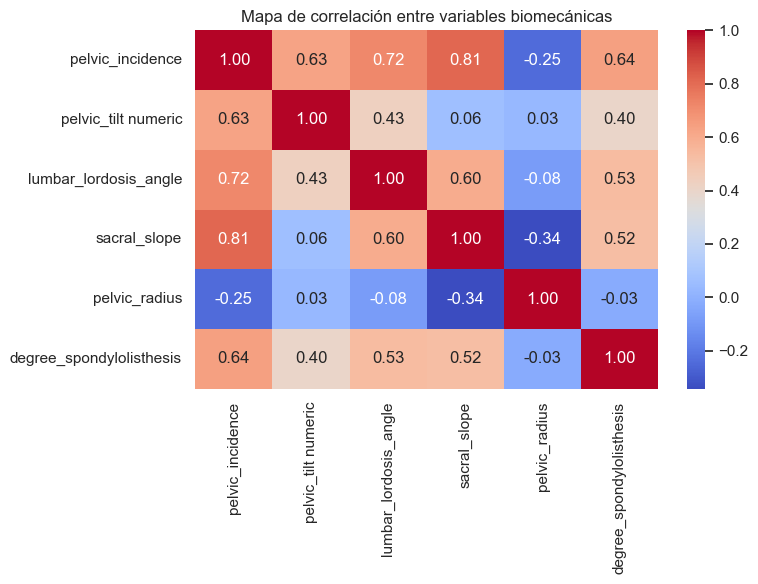

In [23]:
# Crear una matriz de correlación de las variables numéricas
corr = df[features].corr()

# Mostrar el mapa de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Mapa de correlación entre variables biomecánicas")
plt.tight_layout()
plt.show()

sacral_slope presenta una correlacion de 0.81 con pelvic_incidence, mientras que lumbar_lordosis_angle presenta una correlación de 0.72 con pelvic_incidence. Esto es esperado por la anatomía de pelvis y columna. No ostante, se usaran todas las variables porque cada una aporta información biomecánica distinta.

## Preparación de los datos

In [26]:
# 1. Importar librerías necesarias
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2. Separar features y target
# features: columnas numéricas (las 6 variables biomecánicas)
features = [
    "pelvic_incidence",
    "pelvic_tilt numeric",
    "lumbar_lordosis_angle",
    "sacral_slope",
    "pelvic_radius",
    "degree_spondylolisthesis"
]

X = df[features]
y = df["class"]

# 3. Codificar la variable objetivo (class)
y_encoded = y.map({"Normal": 0, "Abnormal": 1})

# 4. Separar train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y_encoded, 
    train_size=0.8, 
    random_state=42
)

# 5. Escalar las variables (StandardScaler)
scaler = StandardScaler()

# Escalar solo train (para aprender la media y std)
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# Escalar test usando el mismo scaler (sin aprender nada nuevo)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# 6. Verificar distribuciones de class en train y test
print("Distribución de class en train:")
print(y_train.value_counts())

print("\nDistribución de class en test:")
print(y_test.value_counts())

# 7. Verificar si hay valores nulos en train y test
print("\nValores nulos en X_train_scaled:")
print(X_train_scaled.isna().sum())

print("\nValores nulos en X_test_scaled:")
print(X_test_scaled.isna().sum())

Distribución de class en train:
class
1    166
0     82
Name: count, dtype: int64

Distribución de class en test:
class
1    44
0    18
Name: count, dtype: int64

Valores nulos en X_train_scaled:
pelvic_incidence            0
pelvic_tilt numeric         0
lumbar_lordosis_angle       0
sacral_slope                0
pelvic_radius               0
degree_spondylolisthesis    0
dtype: int64

Valores nulos en X_test_scaled:
pelvic_incidence            0
pelvic_tilt numeric         0
lumbar_lordosis_angle       0
sacral_slope                0
pelvic_radius               0
degree_spondylolisthesis    0
dtype: int64


# Modelado

## Regresión Logística

In [29]:
# 1. Importar LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix

In [30]:
# 2. Crear el modelo de regresión logística
log_model = LogisticRegression(random_state=42)

In [31]:
# 3. Entrenar el modelo con train
log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [32]:
# 4. Predecir en test
y_pred = log_model.predict(X_test_scaled)

In [33]:
# 5. Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

In [34]:
print(f"Accuracy: {accuracy:.3f}")
print(f"Recall (Abnormal): {recall:.3f}")
print(f"Precision (Abnormal): {precision:.3f}")
print(f"\nMatriz de confusión:")
print(conf_matrix)

Accuracy: 0.871
Recall (Abnormal): 0.909
Precision (Abnormal): 0.909

Matriz de confusión:
[[14  4]
 [ 4 40]]


El modelo tuvo 87,1 % de predicciones correctas, un recall (abnormal) del 90,9% de los pacientes abnormales reales fueron clasificados como abnormales y, una precision del 90,9 % de los predichos abnormales son abnormales.

In [36]:
# 6. Ver coeficientes del modelo
print("\nCoeficientes del modelo:")
for i, feature in enumerate(features):
    print(f"{feature}: {log_model.coef_[0][i]:.3f}")


Coeficientes del modelo:
pelvic_incidence: -0.092
pelvic_tilt numeric: 0.744
lumbar_lordosis_angle: -0.214
sacral_slope: -0.653
pelvic_radius: -0.978
degree_spondylolisthesis: 3.879


Al aumentar degree_spondylolisthesis, aumenta mucho la probabilidad de patología, siendo esta variable la mas importante para detectar patología de columna.

In [38]:
# 7. Ver intercept (constante)
print(f"\nIntercept (constante): {log_model.intercept_[0]:.3f}")


Intercept (constante): 1.946


## Árbol de decisión

In [40]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_model.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [41]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix
)

y_pred_tree = tree_model.predict(X_test_scaled)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree, pos_label=1)
precision_tree = precision_score(y_test, y_pred_tree, pos_label=1)
f1_tree = f1_score(y_test, y_pred_tree, pos_label=1)
conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)

print(f"Accuracy: {accuracy_tree:.3f}")
print(f"Recall (Abnormal): {recall_tree:.3f}")
print(f"Precision (Abnormal): {precision_tree:.3f}")
print(f"F1-score (Abnormal): {f1_tree:.3f}")

print("\nMatriz de confusión:")
print(conf_matrix_tree)

Accuracy: 0.871
Recall (Abnormal): 0.955
Precision (Abnormal): 0.875
F1-score (Abnormal): 0.913

Matriz de confusión:
[[12  6]
 [ 2 42]]


#### Que variables utilizó mas el modelo

In [43]:
import pandas as pd

feature_importance_tree = pd.DataFrame({
    "feature": features,
    "importance": tree_model.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

feature_importance_tree

,feature,importance
5,degree_spondylolisthesis,0.662428
3,sacral_slope,0.177478
4,pelvic_radius,0.136326
1,pelvic_tilt numeric,0.023768
0,pelvic_incidence,0.000000
2,lumbar_lordosis_angle,0.000000


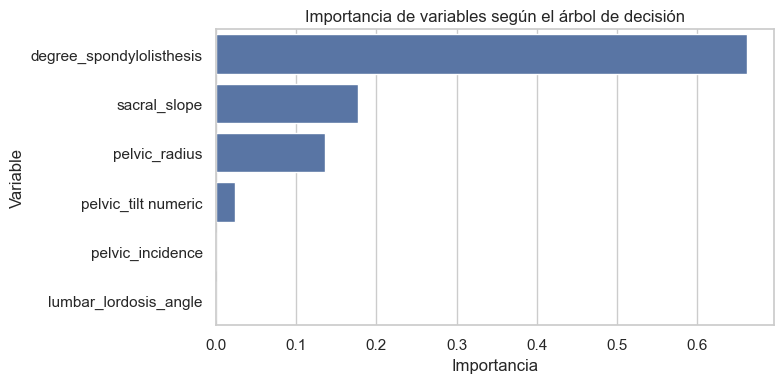

In [44]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=feature_importance_tree,
    x="importance",
    y="feature"
)

plt.title("Importancia de variables según el árbol de decisión")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

Visualización del árbol

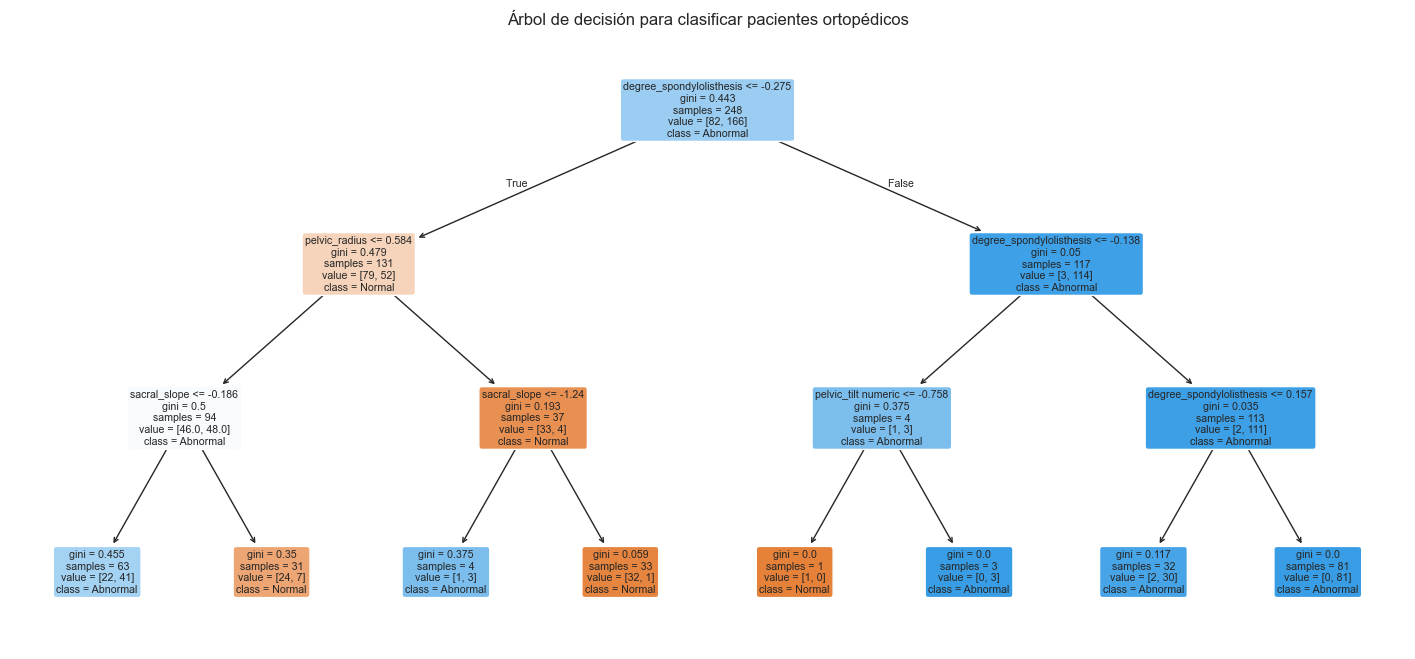

In [46]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))

plot_tree(
    tree_model,
    feature_names=features,
    class_names=["Normal", "Abnormal"],
    filled=True,
    rounded=True
)

plt.title("Árbol de decisión para clasificar pacientes ortopédicos")
plt.show()

#### Entrenamiento del árbol con las variables originales

Usando X_train y X_test, no sus versiones escaladas:

In [76]:
from sklearn.tree import DecisionTreeClassifier

tree_original = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_original.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Evaluación

In [79]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix
)

y_pred_original = tree_original.predict(X_test)

accuracy_original = accuracy_score(y_test, y_pred_original)
recall_original = recall_score(
    y_test,
    y_pred_original,
    pos_label=1
)
precision_original = precision_score(
    y_test,
    y_pred_original,
    pos_label=1
)
f1_original = f1_score(
    y_test,
    y_pred_original,
    pos_label=1
)

print(f"Accuracy: {accuracy_original:.3f}")
print(f"Recall (Abnormal): {recall_original:.3f}")
print(f"Precision (Abnormal): {precision_original:.3f}")
print(f"F1-score (Abnormal): {f1_original:.3f}")

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_original))

Accuracy: 0.871
Recall (Abnormal): 0.955
Precision (Abnormal): 0.875
F1-score (Abnormal): 0.913

Matriz de confusión:
[[12  6]
 [ 2 42]]


Visualizar el árbol

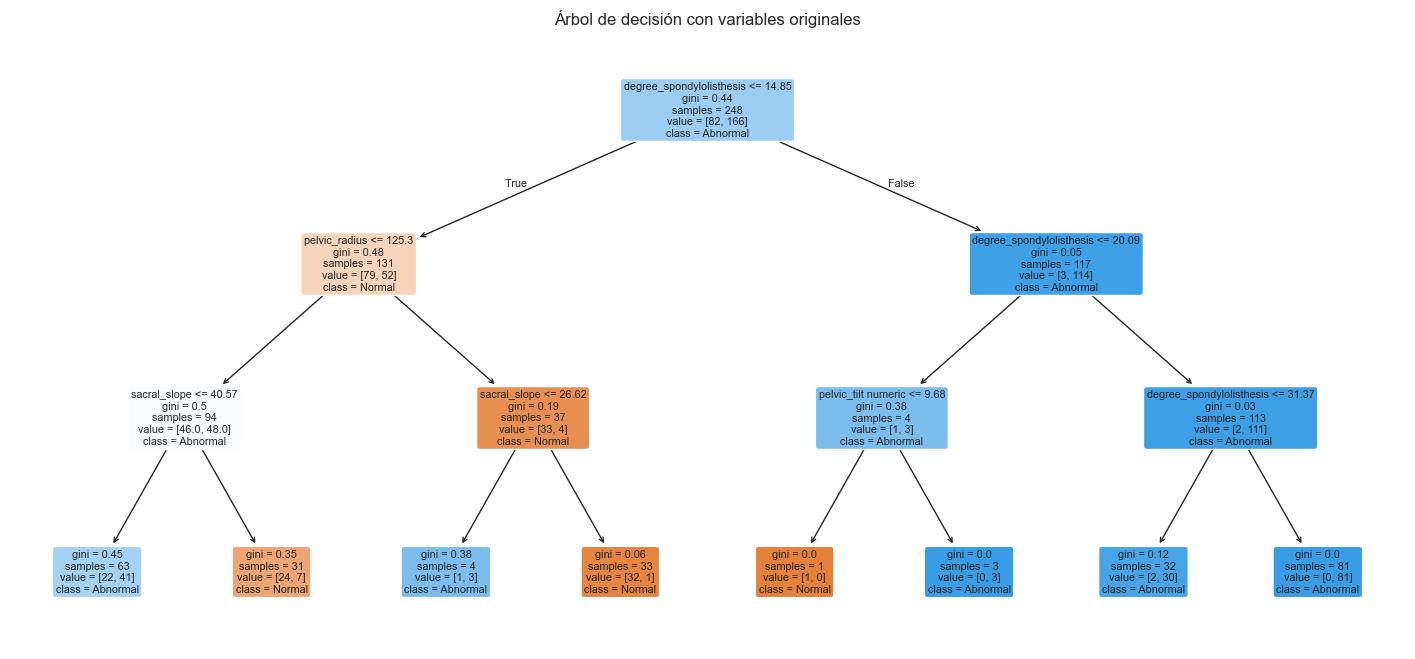

In [82]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))

plot_tree(
    tree_original,
    feature_names=features,
    class_names=["Normal", "Abnormal"],
    filled=True,
    rounded=True,
    precision=2
)

plt.title("Árbol de decisión con variables originales")
plt.show()

Crear los scorers

In [88]:
from sklearn.metrics import (
    make_scorer,
    recall_score,
    precision_score,
    f1_score
)

scoring = {
    "accuracy": "accuracy",
    "recall_abnormal": make_scorer(
        recall_score,
        pos_label="Abnormal"
    ),
    "precision_abnormal": make_scorer(
        precision_score,
        pos_label="Abnormal"
    ),
    "f1_abnormal": make_scorer(
        f1_score,
        pos_label="Abnormal"
    )
}

Validación cruzada estratificada

In [91]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results_tree = cross_validate(
    tree_original,
    X,
    y,
    cv=cv,
    scoring=scoring,
    error_score="raise"
)

Mostrar los resultados

In [94]:
for metric in scoring:
    scores = cv_results_tree[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(± {scores.std():.3f})"
    )

accuracy: 0.819 (± 0.033)
recall_abnormal: 0.871 (± 0.058)
precision_abnormal: 0.866 (± 0.036)
f1_abnormal: 0.867 (± 0.026)


Comparar con la regresión logística

Importar las herramientas

In [104]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

Crear el pipeline de regresión logística

In [107]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

Validar la regresión logística

In [110]:
cv_results_logistic = cross_validate(
    logistic_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring,
    error_score="raise"
)

Mostrar los resultados

In [113]:
for metric in scoring:
    scores = cv_results_logistic[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(± {scores.std():.3f})"
    )

accuracy: 0.852 (± 0.034)
recall_abnormal: 0.890 (± 0.044)
precision_abnormal: 0.895 (± 0.056)
f1_abnormal: 0.891 (± 0.024)


Para entrenar la regresión logística se utilizaron variables estandarizadas. La estandarización es importante para la regresión logística porque sus coeficientes dependen de la escala de las variables. En cambio, el árbol de decisión no necesita estandarización, ya que toma decisiones mediante umbrales. Para la validación cruzada de la regresión logística se utilizó un Pipeline, que incluye el escalado y el modelo. Esto evita que el escalador utilice información de los folds de validación y ayuda a prevenir fuga de información. La regresión logística clasificó correctamente 54 de los 62 registros del conjunto de prueba. Comparado con la regresión logística, el árbol redujo los falsos negativos de 4 a 2, pero aumentó los falsos positivos de 4 a 6. Por eso, en la primera evaluación parecía conveniente elegir el árbol si la prioridad era maximizar el recall de Abnormal. Como el árbol original se entrenó con variables escaladas, los umbrales aparecieron en valores estandarizados. Por esa razón, un valor como -0.275 no representa directamente una unidad clínica original. Se seleccionó la regresión logística como modelo principal porque alcanzó el mejor rendimiento promedio y mostró un buen equilibrio entre recall y precision. El árbol de decisión se conserva como modelo complementario debido a su facilidad de interpretación. Su visualización permite explicar reglas de clasificación de forma intuitiva, aunque su rendimiento promedio fue inferior.

### Ajuste de hiperparámetros del árbol de decisión
Comprobar si una configuración diferente mejora su rendimiento frente a la regresión logística

Definir la búsqueda

In [119]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

tree_base = DecisionTreeClassifier(
    random_state=42
)

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10]
}

Configurar GridSearchCV

In [124]:
from sklearn.metrics import make_scorer, f1_score

f1_abnormal_scorer = make_scorer(
    f1_score,
    pos_label="Abnormal"
)

In [126]:
grid_tree = GridSearchCV(
    estimator=tree_base,
    param_grid=param_grid,
    scoring=f1_abnormal_scorer,
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

Ejecutar la búsqueda

In [129]:
grid_tree.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...abel=Abnormal)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messa

Mostrar la mejor configuración

In [131]:
print("Mejores hiperparámetros:")
print(grid_tree.best_params_)

print("\nMejor F1-score de Abnormal:")
print(f"{grid_tree.best_score_:.3f}")

Mejores hiperparámetros:
{'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 2}

Mejor F1-score de Abnormal:
0.877


Recuperar el mejor árbol

In [133]:
best_tree = grid_tree.best_estimator_

Evaluar el mejor árbol

In [147]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix
)

y_pred_best_tree = best_tree.predict(X_test)

accuracy_best_tree = accuracy_score(
    y_test_text,
    y_pred_best_tree
)

recall_best_tree = recall_score(
    y_test_text,
    y_pred_best_tree,
    pos_label="Abnormal"
)

precision_best_tree = precision_score(
    y_test_text,
    y_pred_best_tree,
    pos_label="Abnormal"
)

f1_best_tree = f1_score(
    y_test_text,
    y_pred_best_tree,
    pos_label="Abnormal"
)

print(f"Accuracy: {accuracy_best_tree:.3f}")
print(f"Recall (Abnormal): {recall_best_tree:.3f}")
print(f"Precision (Abnormal): {precision_best_tree:.3f}")
print(f"F1-score (Abnormal): {f1_best_tree:.3f}")

print("\nMatriz de confusión:")
print(confusion_matrix(
    y_test_text,
    y_pred_best_tree,
    labels=["Normal", "Abnormal"]
))

Accuracy: 0.903
Recall (Abnormal): 0.909
Precision (Abnormal): 0.952
F1-score (Abnormal): 0.930

Matriz de confusión:
[[16  2]
 [ 4 40]]


Comparar árbol original y árbol ajustado

In [ ]:
print("Árbol original")
print(f"Accuracy: {accuracy_original:.3f}")
print(f"Recall: {recall_original:.3f}")
print(f"Precision: {precision_original:.3f}")
print(f"F1-score: {f1_original:.3f}")

print("\nÁrbol ajustado")
print(f"Accuracy: {accuracy_best_tree:.3f}")
print(f"Recall: {recall_best_tree:.3f}")
print(f"Precision: {precision_best_tree:.3f}")
print(f"F1-score: {f1_best_tree:.3f}")

Revisar el sobreajuste comparando el rendimiento de entrenamiento y validación:

In [149]:
results_grid = pd.DataFrame(grid_tree.cv_results_)

results_grid[
    [
        "param_criterion",
        "param_max_depth",
        "param_min_samples_split",
        "param_min_samples_leaf",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10)

,param_criterion,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_train_score,mean_test_score,std_test_score,rank_test_score
59,gini,None,10,10,0.921000,0.877415,0.019754,1
33,gini,4,2,10,0.921000,0.877415,0.019754,1
35,gini,4,10,10,0.921000,0.877415,0.019754,1
45,gini,5,2,10,0.921000,0.877415,0.019754,1
46,gini,5,5,10,0.921000,0.877415,0.019754,1
34,gini,4,5,10,0.921000,0.877415,0.019754,1
57,gini,None,2,10,0.921000,0.877415,0.019754,1
58,gini,None,5,10,0.921000,0.877415,0.019754,1
47,gini,5,10,10,0.921000,0.877415,0.019754,1
18,gini,3,2,5,0.911073,0.871858,0.022565,10


In [155]:
y_test_text = pd.Series(y_test).map({
    0: "Normal",
    1: "Abnormal"
})

In [163]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix
)

accuracy_best_tree = accuracy_score(
    y_test_text,
    y_pred_best_tree
)

recall_best_tree = recall_score(
    y_test_text,
    y_pred_best_tree,
    pos_label="Abnormal"
)

precision_best_tree = precision_score(
    y_test_text,
    y_pred_best_tree,
    pos_label="Abnormal"
)

f1_best_tree = f1_score(
    y_test_text,
    y_pred_best_tree,
    pos_label="Abnormal"
)

print(f"Accuracy: {accuracy_best_tree:.3f}")
print(f"Recall (Abnormal): {recall_best_tree:.3f}")
print(f"Precision (Abnormal): {precision_best_tree:.3f}")
print(f"F1-score (Abnormal): {f1_best_tree:.3f}")

print("\nMatriz de confusión:")
print(
    confusion_matrix(
        y_test_text,
        y_pred_best_tree,
        labels=["Normal", "Abnormal"]
    )
)

Accuracy: 0.903
Recall (Abnormal): 0.909
Precision (Abnormal): 0.952
F1-score (Abnormal): 0.930

Matriz de confusión:
[[16  2]
 [ 4 40]]


Validación cruzada del best_tree

In [168]:
best_tree_cv = cross_validate(
    best_tree,
    X,
    y,
    cv=cv,
    scoring=scoring,
    error_score="raise"
)

for metric in scoring:
    scores = best_tree_cv[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(± {scores.std():.3f})"
    )

accuracy: 0.829 (± 0.026)
recall_abnormal: 0.905 (± 0.034)
precision_abnormal: 0.852 (± 0.020)
f1_abnormal: 0.877 (± 0.020)



Se realizó una búsqueda de hiperparámetros mediante GridSearchCV, optimizan o
el F1-score de la clase Abnormal. Posteriormente, el mejor árbol fue evaluado
mediante validación cruzada estratadac a.

El árbol ajustado obtuvo un accuracy promedio de 0.829, un recall de  .905,
una precision de 0.852 y un F1-score de .877.

En comparación con el árbol original, el ajuste mejoró el accuracy,  l recall
y el F1-score. Sin embargo, la precision disminuyó ligeramente, lo  ue indica
un aumento en la cantidad de falsos ositivos.

La regresión logística obtuvo mejores resultados generales, co  un accuracy
de 0.852, una precision de 0.895 y un F1-score de 0.891. El  rbol ajustado
solo superó a la regresión logística en recall, con valores de 0.905 y 0.890,
 espectivamente.

Por lo tanto, se selecciona la regresión logística como model  principal debido
a su mejor equilibrio general entre las métricas. El árbol a ustado se conserva
como modelo alternativo por su interpretabilidad y por su mayor recall.

Tabla de resultados

In [175]:
import pandas as pd

results_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Tuned Decision Tree"
    ],
    "Accuracy Mean": [
        0.852,
        0.819,
        0.829
    ],
    "Accuracy Std": [
        0.034,
        0.033,
        0.026
    ],
    "Recall Abnormal Mean": [
        0.890,
        0.871,
        0.905
    ],
    "Recall Abnormal Std": [
        0.044,
        0.058,
        0.034
    ],
    "Precision Abnormal Mean": [
        0.895,
        0.866,
        0.852
    ],
    "Precision Abnormal Std": [
        0.056,
        0.036,
        0.020
    ],
    "F1 Abnormal Mean": [
        0.891,
        0.867,
        0.877
    ],
    "F1 Abnormal Std": [
        0.024,
        0.026,
        0.020
    ]
})

results_summary

,Model,Accuracy Mean,Accuracy Std,Recall Abnormal Mean,Recall Abnormal Std,Precision Abnormal Mean,Precision Abnormal Std,F1 Abnormal Mean,F1 Abnormal Std
0,Logistic Regression,0.852,0.034,0.890,0.044,0.895,0.056,0.891,0.024
1,Decision Tree,0.819,0.033,0.871,0.058,0.866,0.036,0.867,0.026
2,Tuned Decision Tree,0.829,0.026,0.905,0.034,0.852,0.020,0.877,0.020


Tabla resumida

In [177]:
results_display = results_summary[
    [
        "Model",
        "Accuracy Mean",
        "Recall Abnormal Mean",
        "Precision Abnormal Mean",
        "F1 Abnormal Mean"
    ]
].copy()

results_display

,Model,Accuracy Mean,Recall Abnormal Mean,Precision Abnormal Mean,F1 Abnormal Mean
0,Logistic Regression,0.852,0.890,0.895,0.891
1,Decision Tree,0.819,0.871,0.866,0.867
2,Tuned Decision Tree,0.829,0.905,0.852,0.877


Identificar el mejor modelo por métrica

In [182]:
metrics_to_compare = [
    "Accuracy Mean",
    "Recall Abnormal Mean",
    "Precision Abnormal Mean",
    "F1 Abnormal Mean"
]

for metric in metrics_to_compare:
    best_model = results_summary.loc[
        results_summary[metric].idxmax(),
        "Model"
    ]

    best_value = results_summary[metric].max()

    print(f"{metric}: {best_model} ({best_value:.3f})")

Accuracy Mean: Logistic Regression (0.852)
Recall Abnormal Mean: Tuned Decision Tree (0.905)
Precision Abnormal Mean: Logistic Regression (0.895)
F1 Abnormal Mean: Logistic Regression (0.891)


Gráfico comparativo

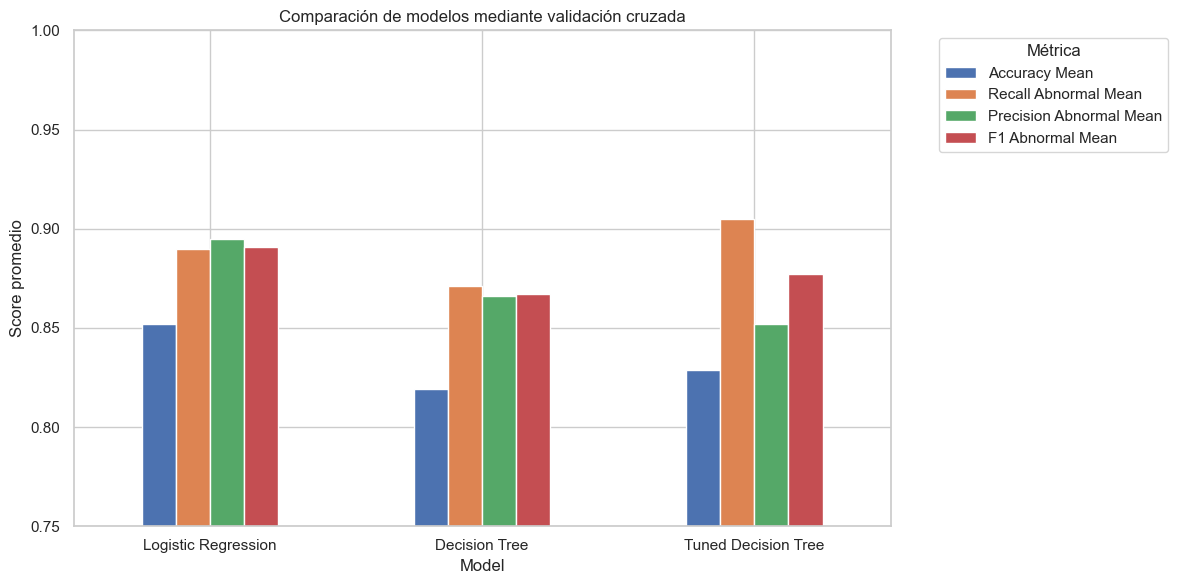

In [185]:
import matplotlib.pyplot as plt

plot_data = results_display.set_index("Model")

plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparación de modelos mediante validación cruzada")
plt.ylabel("Score promedio")
plt.ylim(0.75, 1.00)
plt.xticks(rotation=0)
plt.legend(
    title="Métrica",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

## Comparación final de modelos

Se compararon tres modelos mediante validación cruzada estratificada:
regresión logística, árbol de decisión y árbol de decisión ajustado media te
GridSearchCV.

La regresión logística obtuvo los mejores resultados generales, con un ac uracy
promedio de 0.852, una precision de 0.895 y un F1-score de 0.891 para l  clase
Abnormal.

El árbol de decisión ajustado obtuvo el mayor recall, con un valor p omedio de
0.905. Esto indica que fue el modelo que detectó la mayor proporción de casos
Abnormal. Sin embargo, su precision fue menor, con un valor de 0.852.

Considerando conjuntamente accuracy, precision, recall y F1-score, se seleccionó
la regresión logística como modelo principal. El árbol ajustado s  conserva como
modelo alternativo debido a su mayor recall y a la facilidad de interpretar sus
reglas de decisión.

La selección final depende del objetivo de la aplicación. Si  e prioriza reducir
los falsos negativos, el árbol ajustado puede ser una alter ativa válida. Si se
busca un equilibrio general entre detección y reducción  e falsas alarmas, la
regresión logística presenta el mejor rendimiento.